#  Analyse des Métriques de Performance Employés
**Objectif :** Évaluer l'efficacité de la force de vente à travers des indicateurs de performance clés (KPIs).

### Indicateurs analysés :
1. **Chiffre d'Affaires (Revenue)** : La contribution financière totale de chaque commercial.
2. **Nombre de Clients Gérés** : L'étendue du portefeuille client.
3. **Panier Moyen par Employé** : La capacité du commercial à maximiser la valeur de chaque commande (qualité de la vente).

**Enjeu Business :** Identifier les "Top Performers" pour le partage des meilleures pratiques et l'attribution des primes annuelles.

Extraction des indicateurs de performance employés...


c:\Users\salma\classicmodels-analysis\src\analysis\connection.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


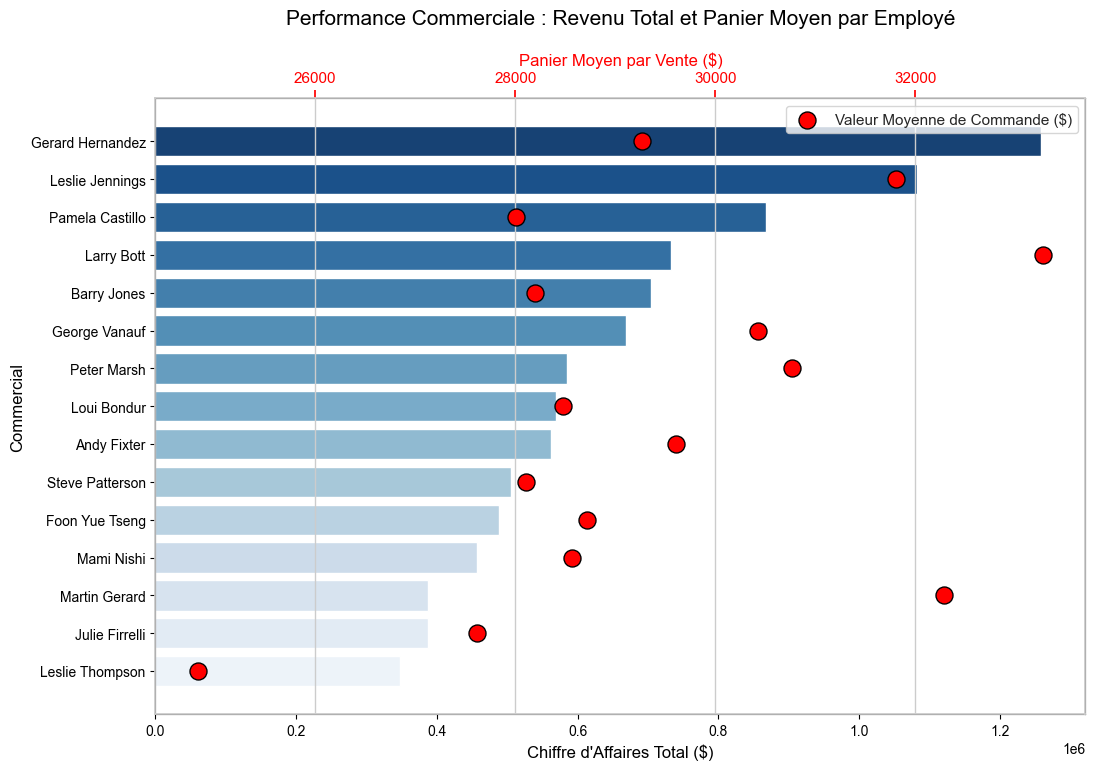

Classement par Revenu :
      employee_name  total_revenue  nb_clients  avg_basket_per_emp
0  Gerard Hernandez     1258577.81           7        29269.251395
1   Leslie Jennings     1081530.54           6        31809.721765
2   Pamela Castillo      868220.55          10        28007.114516
3        Larry Bott      732096.79           8        33277.126818
4       Barry Jones      704853.91           9        28194.156400


In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. CONFIGURATION DU CHEMIN
sys.path.append(os.path.abspath(os.path.join('..')))
from src.analysis.connection import get_db_data 

# 2. EXTRACTION DES DONNÉES DE PERFORMANCE
print("Extraction des indicateurs de performance employés...")
query_emp_perf = """
    SELECT 
        CONCAT(e.firstName, ' ', e.lastName) AS employee_name,
        COUNT(DISTINCT o.orderNumber) AS nb_orders,
        COUNT(DISTINCT c.customerNumber) AS nb_clients,
        SUM(od.quantityOrdered * od.priceEach) AS total_revenue
    FROM employees e
    JOIN customers c ON e.employeeNumber = c.salesRepEmployeeNumber
    JOIN orders o ON c.customerNumber = o.customerNumber
    JOIN orderdetails od ON o.orderNumber = od.orderNumber
    GROUP BY e.employeeNumber
    ORDER BY total_revenue DESC;
"""
df_emp = get_db_data(query_emp_perf)

# 3. CALCUL DU PANIER MOYEN PAR EMPLOYÉ
# Qualité de la vente : CA Total / Nombre de commandes
df_emp['avg_basket_per_emp'] = df_emp['total_revenue'] / df_emp['nb_orders']

# 4. VISUALISATION DOUBLE AXE (REVENU ET PANIER MOYEN)
fig, ax1 = plt.subplots(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Barres pour le Revenu Total
sns.barplot(
    data=df_emp, 
    x='total_revenue', 
    y='employee_name', 
    ax=ax1, 
    palette='Blues_r', 
    hue='employee_name', 
    legend=False
)
ax1.set_title('Performance Commerciale : Revenu Total et Panier Moyen par Employé', fontsize=15, pad=20)
ax1.set_xlabel('Chiffre d\'Affaires Total ($)', fontsize=12)
ax1.set_ylabel('Commercial', fontsize=12)

# Ajout d'un deuxième axe pour le Panier Moyen (Point de vue qualitatif)
ax2 = ax1.twiny()
sns.scatterplot(
    data=df_emp, 
    x='avg_basket_per_emp', 
    y='employee_name', 
    ax=ax2, 
    color='red', 
    s=150, 
    label='Valeur Moyenne de Commande ($)',
    edgecolor='black'
)
ax2.set_xlabel('Panier Moyen par Vente ($)', fontsize=12, color='red')
ax2.tick_params(axis='x', colors='red')

# Sauvegarde
save_path_emp = os.path.join('..', 'visualisations', 'employee_performance_metrics.png')
plt.savefig(save_path_emp, bbox_inches='tight', dpi=300)
plt.show()

# Affichage des statistiques pour le rapport
print("Classement par Revenu :")
print(df_emp[['employee_name', 'total_revenue', 'nb_clients', 'avg_basket_per_emp']].head(5))

/ Analyse de la Performance Commerciale : Revenu et Panier Moyen
Cette analyse permet de sortir d'un simple classement par chiffre d'affaires pour évaluer l'efficacité réelle de chaque commercial et leur stratégie de vente (volume vs valeur).

--> Constats de l'Analyse (Interprétation des Données)
Le graphique présente deux indicateurs clés : les barres bleues représentent le chiffre d'affaires (CA) total, tandis que les points rouges indiquent la valeur moyenne des ventes (panier moyen) réalisées par chaque employé.

- Gerard Hernandez : Il arrive en tête avec un CA dépassant les 1,25 million $. Son panier moyen est solide (autour de 29 000 $), ce qui montre une excellente gestion d'un portefeuille client actif.

- Larry Bott & Martin Gerard : Ces deux commerciaux n'ont pas le CA le plus élevé, mais ils possèdent les paniers moyens les plus élevés du groupe (dépassant les 32 000 $). Cela indique qu'ils gèrent probablement des comptes "Grands Comptes" ou qu'ils sont très performants en vente additionnelle (up-selling).

- Pamela Castillo : Elle gère le plus grand nombre de clients (10 clients), mais son panier moyen est l'un des plus bas. Sa performance repose sur la quantité de relations gérées plutôt que sur la valeur unitaire des transactions.

- Leslie Thompson : Elle présente le CA et le panier moyen les plus faibles. Un diagnostic est nécessaire pour comprendre s'il s'agit d'un manque de formation ou d'un secteur géographique moins porteur.